# TabNet Hyperparameter Tuning for Customer Churn

In [1]:
from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import seaborn as sns
import torch

from optuna.samplers import TPESampler
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    auc,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

# Set random seeds for reproducibility
SEED = 42
N_TRIALS = 10
MAX_EPOCHS = 20
PATIENCE = 5
BATCH_SIZE = 2048
VIRTUAL_BATCH_SIZE = 256
ARTIFACT_DIR = Path("tabnet_optuna_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Optuna version: {optuna.__version__}")
print(f"PyTorch device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

c:\Users\User\ODL_Labs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optuna version: 4.9.0
PyTorch device: cuda


### Data Setup

In [4]:
# Load the train/validation/test datasets
train_df = pd.read_csv("../data/train_churn_dataset.csv")
val_df = pd.read_csv("../data/val_churn_dataset.csv")
test_df = pd.read_csv("../data/test_churn_dataset.csv")

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (314599, 13)
Validation shape: (67414, 13)
Test shape: (67415, 13)


In [18]:
# Set target column and identify feature columns
TARGET = "Churn"
feature_names = [col for col in train_df.columns if col != TARGET]

# Prepare training, validation, and test datasets for TabNet
X_train = train_df[feature_names].astype(np.float32)
y_train = train_df[TARGET].astype(np.int64)

X_val = val_df[feature_names].astype(np.float32)
y_val = val_df[TARGET].astype(np.int64)

X_test = test_df[feature_names].astype(np.float32)
y_test = test_df[TARGET].astype(np.int64)

### Model Building

In [ ]:
# Build the TabNet model with hyperparameters from Optuna
def build_tabnet(params):
    return TabNetClassifier(
        n_d=params["n_d"],
        n_a=params["n_d"],
        n_steps=params["n_steps"],
        gamma=params["gamma"],
        lambda_sparse=1e-4,
        mask_type="sparsemax",
        optimizer_fn=torch.optim.Adam,
        optimizer_params={
            "lr": params["learning_rate"],
            "weight_decay": 1e-5,
        },
        seed=SEED,
        verbose=1,
        device_name="auto",
    )

In [21]:
from sklearn.metrics import accuracy_score

# Objective function for Optuna hyperparameter optimization
def objective(trial):
    n_d = trial.suggest_int("n_d", 8, 64, step=8)
    params = {
        "n_d": n_d,
        "n_a": n_d,  # tied with n_d
        "n_steps": trial.suggest_int("n_steps", 3, 8),
        "gamma": trial.suggest_categorical("gamma", [1.0, 2.0]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True),
    }

    # Build and train the TabNet model with the suggested hyperparameters
    model = build_tabnet(params)
    model.fit(
        X_train=X_train.values,
        y_train=y_train.values,
        eval_set=[(X_val.values, y_val.values)],
        eval_name=["valid"],
        eval_metric=["logloss"],
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        batch_size=BATCH_SIZE,
        virtual_batch_size=VIRTUAL_BATCH_SIZE,
        num_workers=0,
        drop_last=False,
    )

    # Evaluate the model on the validation set and return the accuracy
    validation_prediction = model.predict(X_val.values)
    validation_accuracy = accuracy_score(y_val.values, validation_prediction)
    trial.set_user_attr("validation_accuracy", float(validation_accuracy))
    trial.set_user_attr("best_epoch", int(model.best_epoch))
    return validation_accuracy

print("Objective function is ready.")

Objective function is ready.


### Model Tuning with Optuna

In [22]:
# Create the optuna study and run the optimization
sampler = TPESampler(seed=SEED)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="tabnet_churn",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

[I 2026-09-07 21:41:58,899] A new study created in memory with name: tabnet_churn
  0%|          | 0/10 [00:00<?, ?it/s]

epoch 0  | loss: 1.05416 | valid_logloss: 0.63526 |  0:00:17s
epoch 1  | loss: 0.53545 | valid_logloss: 0.46751 |  0:00:34s
epoch 2  | loss: 0.4487  | valid_logloss: 0.42309 |  0:00:51s
epoch 3  | loss: 0.40961 | valid_logloss: 0.39244 |  0:01:06s
epoch 4  | loss: 0.38461 | valid_logloss: 0.372   |  0:01:36s
epoch 5  | loss: 0.36529 | valid_logloss: 0.35537 |  0:02:03s
epoch 6  | loss: 0.35046 | valid_logloss: 0.34083 |  0:02:24s
epoch 7  | loss: 0.33757 | valid_logloss: 0.32668 |  0:02:48s
epoch 8  | loss: 0.32653 | valid_logloss: 0.31791 |  0:03:06s
epoch 9  | loss: 0.31897 | valid_logloss: 0.30874 |  0:03:24s
epoch 10 | loss: 0.30877 | valid_logloss: 0.30203 |  0:03:43s
epoch 11 | loss: 0.30212 | valid_logloss: 0.29536 |  0:04:02s
epoch 12 | loss: 0.29623 | valid_logloss: 0.29006 |  0:04:20s
epoch 13 | loss: 0.28972 | valid_logloss: 0.28402 |  0:04:38s
epoch 14 | loss: 0.28395 | valid_logloss: 0.27892 |  0:04:56s
epoch 15 | loss: 0.28018 | valid_logloss: 0.274   |  0:05:13s
epoch 16

Best trial: 0. Best value: 0.90904:  10%|█         | 1/10 [06:35<59:16, 395.16s/it]

[I 2026-09-07 21:48:34,054] Trial 0 finished with value: 0.9090396653514107 and parameters: {'n_d': 24, 'n_steps': 8, 'gamma': 1.0, 'learning_rate': 0.0002636875533972306}. Best is trial 0 with value: 0.9090396653514107.
epoch 0  | loss: 0.35597 | valid_logloss: 0.28416 |  0:00:08s
epoch 1  | loss: 0.25881 | valid_logloss: 0.24447 |  0:00:16s
epoch 2  | loss: 0.23734 | valid_logloss: 0.23178 |  0:00:23s
epoch 3  | loss: 0.23174 | valid_logloss: 0.22912 |  0:00:33s
epoch 4  | loss: 0.22878 | valid_logloss: 0.22882 |  0:00:42s
epoch 5  | loss: 0.22737 | valid_logloss: 0.22424 |  0:00:51s
epoch 6  | loss: 0.22392 | valid_logloss: 0.22173 |  0:01:00s
epoch 7  | loss: 0.2219  | valid_logloss: 0.21786 |  0:01:08s
epoch 8  | loss: 0.22052 | valid_logloss: 0.21585 |  0:01:18s
epoch 9  | loss: 0.22013 | valid_logloss: 0.21957 |  0:01:27s
epoch 10 | loss: 0.21842 | valid_logloss: 0.21749 |  0:01:35s
epoch 11 | loss: 0.21912 | valid_logloss: 0.21764 |  0:01:42s
epoch 12 | loss: 0.21729 | valid_lo

Best trial: 1. Best value: 0.924126:  20%|██        | 2/10 [09:29<35:20, 265.10s/it]

...

[I 2026-09-07 22:19:23,599] Trial 7 finished with value: 0.9188892514907883 and parameters: {'n_d': 56, 'n_steps': 4, 'gamma': 2.0, 'learning_rate': 0.0015415527060141947}. Best is trial 1 with value: 0.9241255525558489.
epoch 0  | loss: 0.70994 | valid_logloss: 0.59479 |  0:00:17s
epoch 1  | loss: 0.55967 | valid_logloss: 0.52524 |  0:00:32s
epoch 2  | loss: 0.50882 | valid_logloss: 0.48307 |  0:00:48s
epoch 3  | loss: 0.47404 | valid_logloss: 0.45277 |  0:01:05s
epoch 4  | loss: 0.44651 | valid_logloss: 0.429   |  0:01:28s
epoch 5  | loss: 0.42598 | valid_logloss: 0.41332 |  0:01:44s
epoch 6  | loss: 0.41468 | valid_logloss: 0.40395 |  0:01:59s
epoch 7  | loss: 0.40507 | valid_logloss: 0.39578 |  0:02:13s
epoch 8  | loss: 0.39516 | valid_logloss: 0.38697 |  0:02:30s
epoch 9  | loss: 0.39098 | valid_logloss: 0.38335 |  0:02:44s
epoch 10 | loss: 0.38611 | valid_logloss: 0.3807  |  0:02:58s
epoch 11 | loss: 0.38267 | valid_logloss: 0.37589 |  0:03:13s
epoch 12 | loss: 0.37911 | valid_lo

Best trial: 1. Best value: 0.924126:  90%|█████████ | 9/10 [42:16<04:34, 274.63s/it]

[I 2026-09-07 22:24:15,143] Trial 8 finished with value: 0.8716735396208503 and parameters: {'n_d': 8, 'n_steps': 5, 'gamma': 2.0, 'learning_rate': 0.0004993895014755662}. Best is trial 1 with value: 0.9241255525558489.
epoch 0  | loss: 0.7541  | valid_logloss: 0.48498 |  0:00:09s
epoch 1  | loss: 0.45058 | valid_logloss: 0.42825 |  0:00:17s
epoch 2  | loss: 0.4101  | valid_logloss: 0.3954  |  0:00:26s
epoch 3  | loss: 0.38784 | valid_logloss: 0.37935 |  0:00:35s
epoch 4  | loss: 0.37231 | valid_logloss: 0.36421 |  0:00:45s
epoch 5  | loss: 0.36121 | valid_logloss: 0.35186 |  0:00:55s
epoch 6  | loss: 0.34906 | valid_logloss: 0.34164 |  0:01:04s
epoch 7  | loss: 0.34089 | valid_logloss: 0.33587 |  0:01:13s
epoch 8  | loss: 0.33117 | valid_logloss: 0.32535 |  0:01:22s
epoch 9  | loss: 0.32284 | valid_logloss: 0.31748 |  0:01:33s
epoch 10 | loss: 0.31711 | valid_logloss: 0.31082 |  0:01:43s
epoch 11 | loss: 0.30953 | valid_logloss: 0.30296 |  0:01:54s
epoch 12 | loss: 0.3034  | valid_log

Best trial: 1. Best value: 0.924126: 100%|██████████| 10/10 [45:37<00:00, 273.79s/it]

[I 2026-09-07 22:27:36,767] Trial 9 finished with value: 0.9035956922894355 and parameters: {'n_d': 48, 'n_steps': 4, 'gamma': 2.0, 'learning_rate': 0.0003154399030833099}. Best is trial 1 with value: 0.9241255525558489.


In [26]:
# Display the best trial and its hyperparameters
best_trial = study.best_trial
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:       {best_trial.number}")
print(f"  Best epoch:     {best_trial.user_attrs.get('best_epoch')}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# Save study results so the search does not need to be repeated
study_df = study.trials_dataframe()
study_df.to_csv(ARTIFACT_DIR / "optuna_trials.csv", index=False)
with open(ARTIFACT_DIR / "best_params.json", "w") as f:
    json.dump(best_trial.params, f, indent=2)

Number of finished trials: 10
Best trial:       1
  Best epoch:     19
  Params:
    n_d: 16
    n_steps: 3
    gamma: 1.0
    learning_rate: 0.008148293210105292


### Train final model with best hyperparameters

In [28]:
# Build the final model with the best hyperparameters
best_params = study.best_trial.params
final_model = build_tabnet(best_params)

# Train the final model
final_model.fit(
    X_train=X_train.values,
    y_train=y_train.values,
    eval_set=[(X_train.values, y_train.values), (X_val.values, y_val.values)],
    eval_name=["train", "valid"],
    eval_metric=["logloss"],
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    num_workers=0,
    drop_last=False,
)

# Save the final model
saved_path = final_model.save_model(str(ARTIFACT_DIR / "tabnet_best_model"))
print(f"Best epoch: {final_model.best_epoch}")
print(f"Model saved to: {saved_path}")


epoch 0  | loss: 0.35597 | train_logloss: 0.28008 | valid_logloss: 0.28416 |  0:00:11s
epoch 1  | loss: 0.25803 | train_logloss: 0.23611 | valid_logloss: 0.23944 |  0:00:19s
epoch 2  | loss: 0.23743 | train_logloss: 0.22899 | valid_logloss: 0.23269 |  0:00:28s
epoch 3  | loss: 0.23181 | train_logloss: 0.22355 | valid_logloss: 0.22748 |  0:00:37s
epoch 4  | loss: 0.22865 | train_logloss: 0.22479 | valid_logloss: 0.22828 |  0:00:45s
epoch 5  | loss: 0.22474 | train_logloss: 0.21803 | valid_logloss: 0.22157 |  0:00:54s
epoch 6  | loss: 0.22314 | train_logloss: 0.21574 | valid_logloss: 0.21972 |  0:01:02s
epoch 7  | loss: 0.222   | train_logloss: 0.21705 | valid_logloss: 0.22136 |  0:01:11s
epoch 8  | loss: 0.21999 | train_logloss: 0.2138  | valid_logloss: 0.21721 |  0:01:19s
epoch 9  | loss: 0.21815 | train_logloss: 0.21142 | valid_logloss: 0.21567 |  0:01:28s
epoch 10 | loss: 0.2182  | train_logloss: 0.21138 | valid_logloss: 0.21463 |  0:01:36s
epoch 11 | loss: 0.21796 | train_logloss: 0

### Model Evaluation

In [43]:
test_probability = final_model.predict_proba(X_test.values)[:, 1]
test_prediction = (test_probability > 0.5).astype(int)

report = classification_report(y_test, test_prediction, output_dict=True)
accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"TUNED TABNET CLASSIFICATION REPORT:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

TUNED TABNET CLASSIFICATION REPORT:
Accuracy:  0.9248
Precision: 0.8748
Recall:    0.9915
F1-score:  0.9295


#### ROC curve

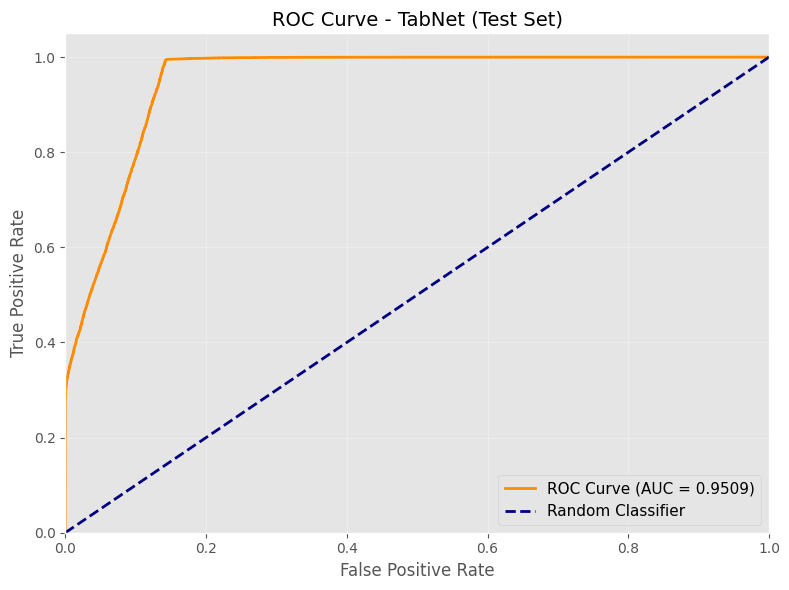

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, test_probability)

test_auc = roc_auc_score(y_test, test_probability)

# Visualize the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - TabNet (Test Set)", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Confusion matrix

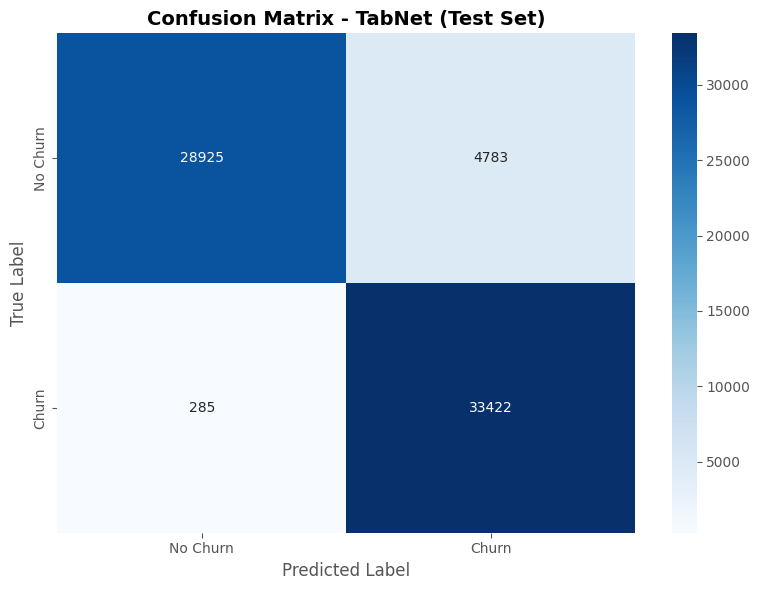

In [ ]:
# Visualize the confusion matrix
cm = confusion_matrix(y_test, test_prediction)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix - TabNet (Test Set)", fontsize=14, fontweight="bold")
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()


#### Feature importance

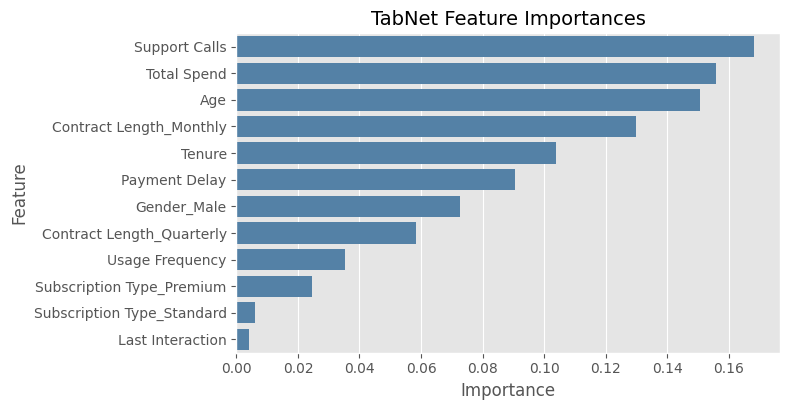

In [53]:
importances = (
    pd.Series(final_model.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, max(4, 0.35 * len(importances))))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("TabNet Feature Importances", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

importances.to_frame("importance").to_csv(ARTIFACT_DIR / "feature_importances.csv")


### View saved items

In [54]:
print("Artifacts written to:", ARTIFACT_DIR.resolve())
for path in sorted(ARTIFACT_DIR.glob("*")):
    print(" -", path.name)


Artifacts written to: C:\Users\User\ODL_Labs\Assignment\training\tabnet_optuna_artifacts
 - best_params.json
 - feature_importances.csv
 - optuna_trials.csv
 - tabnet_best_model.zip
